<a href="https://colab.research.google.com/github/samarasimhareddymatla-sys/air-pollution-prediction/blob/main/Air_Quality_Prediction_%26_Pollution_Hotspot_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving pollution_3000.csv to pollution_3000 (2).csv
✅ Dataset Loaded Successfully
Initial Shape: (3000, 16)
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
Shape after reducing: (3000, 16)
Shape after cleaning: (610, 16)

🔎 Dataset Info:

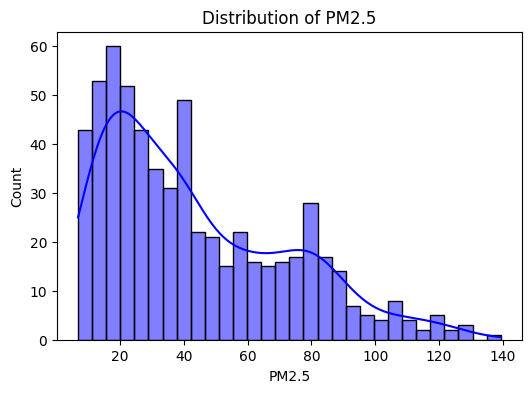

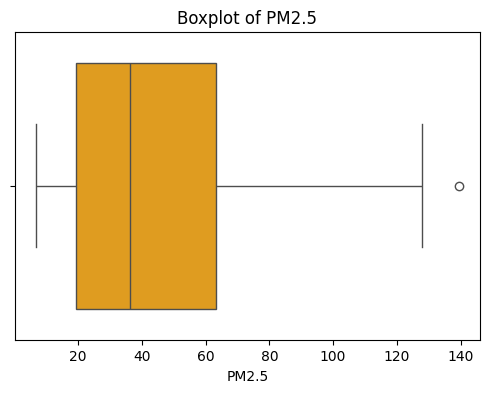

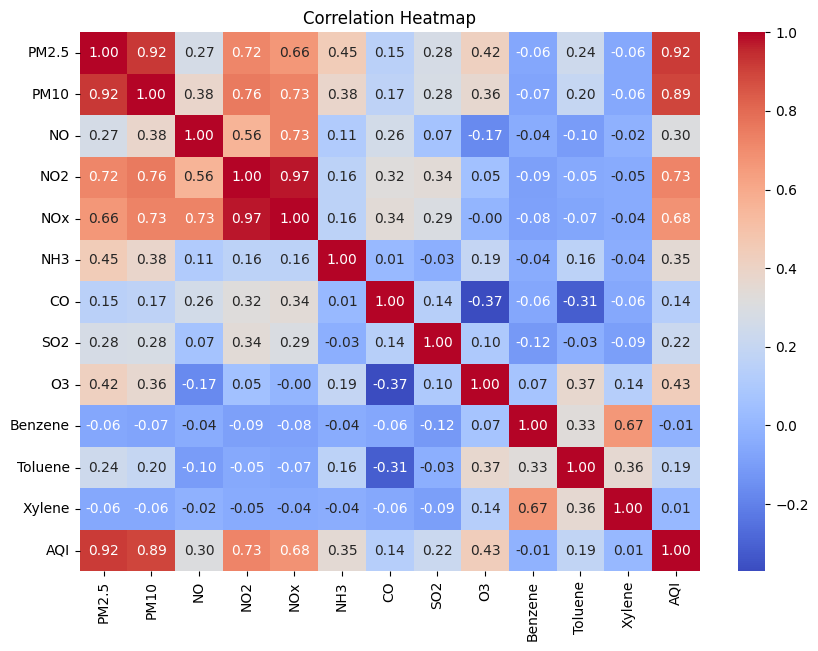

Feature matrix shape: (610, 12)
Target vector shape: (610,)
Linear Regression Performance:
MSE: 69.51705230538212
R2 Score: 0.9101453232778939
Random Forest Performance:
MSE: 38.55843490016393
R2 Score: 0.9501610671343674
Model Comparison:
               Model        MSE  R2 Score
0  Linear Regression  69.517052  0.910145
1      Random Forest  38.558435  0.950161


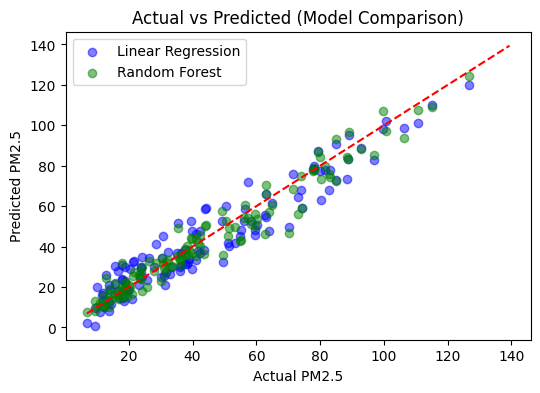

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
#Load Dataset
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df=pd.read_csv("/content/pollution_3000.csv")
print("✅ Dataset Loaded Successfully")
print("Initial Shape:", df.shape)
print(df.head())
df = df.head(3000)
print("Shape after reducing:", df.shape)
#Data Cleaning
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Drop rows with missing values
df = df.dropna()
print("Shape after cleaning:", df.shape)
if df.shape[0] == 0:
    raise ValueError("⚠️ After cleaning, dataset is empty. Please check the CSV file!")
#Exploratory Data Analysis (EDA)
print("\n🔎 Dataset Info:")
print(df.info())
print("\n🔎 Statistical Summary:")
print(df.describe())
# Distribution of PM2.5
if "PM2.5" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df['PM2.5'], bins=30, kde=True, color="blue")
    plt.title("Distribution of PM2.5")
    plt.show()
    #Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df['PM2.5'], color="orange")
    plt.title("Boxplot of PM2.5")
    plt.show()

#Correlation Heatmap (only numeric columns)
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#Feature Selection
if "PM2.5" in df.columns:
    X = df.drop("PM2.5", axis=1)
    # Keep only numeric features (ignore city names etc.)
    X = X.select_dtypes(include=[np.number])
    y = df["PM2.5"]
    print("Feature matrix shape:", X.shape)
    print("Target vector shape:", y.shape)
else:
    raise ValueError("PM2.5 column not found in dataset")
#Train-Test Split
if X.shape[0] > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    raise ValueError("Feature matrix is empty. Cannot split data.")
#Linear Regression Model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
y_pred_lin = lin_model.predict(X_test)
print("Linear Regression Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_lin))
print("R2 Score:", r2_score(y_test, y_pred_lin))
#Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Performance:")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))
#Compare Models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MSE": [mean_squared_error(y_test, y_pred_lin),
            mean_squared_error(y_test, y_pred_rf)],
    "R2 Score": [r2_score(y_test, y_pred_lin),
                 r2_score(y_test, y_pred_rf)]
})
print("Model Comparison:")
print(results)
#Plot Predictions vs Actual
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_lin, alpha=0.5, label="Linear Regression", color="blue")
plt.scatter(y_test, y_pred_rf, alpha=0.5, label="Random Forest", color="green")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual PM2.5")

plt.ylabel("Predicted PM2.5")
plt.legend()
plt.title("Actual vs Predicted (Model Comparison)")
plt.show()







